# 02 - Fraud Analysis

Detailed analysis of fraud patterns, transaction types, balance discrepancies, and anomalies.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/raw/Fraud.csv"

df = pd.read_csv(DATA_PATH)

sns.set_theme(style="whitegrid")

In [2]:
quality_checks = {
    "negative_amounts": int((df["amount"] < 0).sum()),
    "negative_old_sender_balances": int((df["oldbalanceOrg"] < 0).sum()),
    "negative_new_sender_balances": int((df["newbalanceOrig"] < 0).sum()),
    "negative_old_receiver_balances": int((df["oldbalanceDest"] < 0).sum()),
    "negative_new_receiver_balances": int((df["newbalanceDest"] < 0).sum()),
    "zero_amount_transactions": int((df["amount"] == 0).sum()),
    "unique_transaction_types": int(df["type"].nunique()),
    "minimum_step": int(df["step"].min()),
    "maximum_step": int(df["step"].max()),
}

pd.Series(quality_checks, name="value")

negative_amounts                    0
negative_old_sender_balances        0
negative_new_sender_balances        0
negative_old_receiver_balances      0
negative_new_receiver_balances      0
zero_amount_transactions           16
unique_transaction_types            5
minimum_step                        1
maximum_step                      743
Name: value, dtype: int64

In [3]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [4]:
amount_quantiles = (
    df.groupby("isFraud")["amount"]
      .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
      .unstack()
)

amount_quantiles.index = ["Legitimate", "Fraud"]
amount_quantiles

,0.25,0.50,0.75,0.90,0.95,0.99
Legitimate,13368.395,74684.72,208364.76,364373.444,515610.423,1.586064e+06
Fraud,127091.330,441423.44,1517771.48,4521723.512,8006429.040,1.000000e+07


In [5]:
df["log_amount"] = np.log1p(df["amount"])

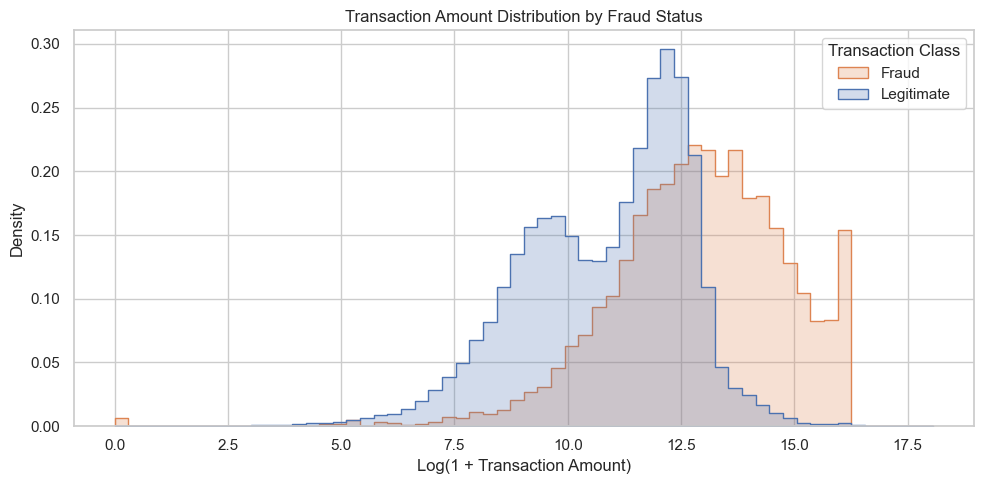

In [9]:
sample_legitimate = df[df["isFraud"] == 0].sample(
    n=50_000,
    random_state=42
)

all_fraud = df[df["isFraud"] == 1]

plot_data = pd.concat([sample_legitimate, all_fraud])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=plot_data,
    x="log_amount",
    hue="isFraud",
    bins=60,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Log(1 + Transaction Amount)")
plt.ylabel("Density")
plt.legend(title="Transaction Class", labels=["Fraud", "Legitimate"])
plt.tight_layout()
plt.show()

In [10]:
hourly_fraud = (
    df.groupby("step")
      .agg(
          transactions=("isFraud", "size"),
          frauds=("isFraud", "sum"),
          transaction_value=("amount", "sum")
      )
)

fraud_value_by_step = (
    df.assign(fraudulent_value=df["amount"] * df["isFraud"])
      .groupby("step")["fraudulent_value"]
      .sum()
)

hourly_fraud["fraudulent_value"] = fraud_value_by_step

hourly_fraud["fraud_rate"] = (
    hourly_fraud["frauds"] / hourly_fraud["transactions"]
)

hourly_fraud["fraud_rate_24h"] = (
    hourly_fraud["fraud_rate"]
    .rolling(window=24, min_periods=1)
    .mean()
)

hourly_fraud.head()

,transactions,frauds,transaction_value,fraudulent_value,fraud_rate,fraud_rate_24h
step,,,,,,
1,2708,16,2.854292e+08,3740247.01,0.005908,0.005908
2,1014,8,8.592160e+07,4186592.48,0.007890,0.006899
3,552,4,4.329388e+07,66832.74,0.007246,0.007015
4,565,10,7.291003e+07,26400274.90,0.017699,0.009686
5,665,6,4.554809e+07,381841.54,0.009023,0.009553


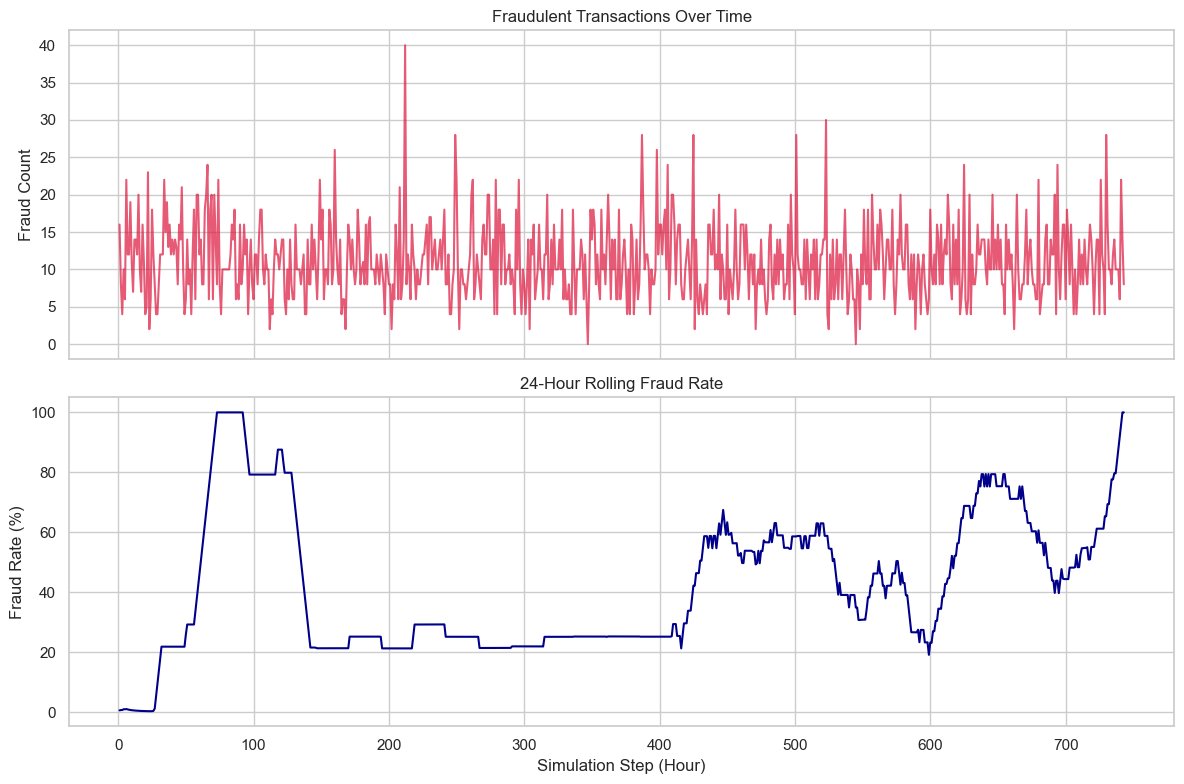

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    hourly_fraud.index,
    hourly_fraud["frauds"],
    color="crimson",
    alpha=0.7
)
axes[0].set_title("Fraudulent Transactions Over Time")
axes[0].set_ylabel("Fraud Count")

axes[1].plot(
    hourly_fraud.index,
    hourly_fraud["fraud_rate_24h"] * 100,
    color="darkblue"
)
axes[1].set_title("24-Hour Rolling Fraud Rate")
axes[1].set_xlabel("Simulation Step (Hour)")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [12]:
df["sender_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
).abs()

df["receiver_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
).abs()

df["emptied_sender"] = (
    (df["oldbalanceOrg"] > 0)
    & (df["newbalanceOrig"] == 0)
).astype("int8")

df["amount_to_sender_balance"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

df[
    [
        "sender_balance_error",
        "receiver_balance_error",
        "emptied_sender",
        "amount_to_sender_balance"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
sender_balance_error,6362620.0,201092.468248,606650.460075,0.0,2954.230000,68677.255000,249641.0875,92445516.64
receiver_balance_error,6362620.0,93599.071898,435056.981486,0.0,0.000000,5123.620000,43421.3300,75885725.63
emptied_sender,6362620.0,0.238987,0.426465,0.0,0.000000,0.000000,0.0000,1.00
amount_to_sender_balance,6362620.0,70674.476792,508424.269379,0.0,0.234401,6.453832,12287.7650,92445516.64


In [13]:
balance_comparison = (
    df.groupby("isFraud")
      .agg(
          median_sender_error=("sender_balance_error", "median"),
          mean_sender_error=("sender_balance_error", "mean"),
          median_receiver_error=("receiver_balance_error", "median"),
          mean_receiver_error=("receiver_balance_error", "mean"),
          emptied_sender_rate=("emptied_sender", "mean"),
          median_amount_balance_ratio=(
              "amount_to_sender_balance",
              "median"
          )
      )
)

balance_comparison.index = ["Legitimate", "Fraud"]
balance_comparison

,median_sender_error,mean_sender_error,median_receiver_error,mean_receiver_error,emptied_sender_rate,median_amount_balance_ratio
Legitimate,69049.31,201338.558304,5123.10,92756.964361,0.238035,6.511566
Fraud,0.00,10692.325265,9511.69,745138.585637,0.975527,0.999998


In [14]:
fraud_balance_by_type = (
    df[df["isFraud"] == 1]
      .groupby("type")
      .agg(
          fraud_count=("isFraud", "size"),
          median_amount=("amount", "median"),
          median_sender_error=("sender_balance_error", "median"),
          median_receiver_error=("receiver_balance_error", "median"),
          emptied_sender_rate=("emptied_sender", "mean")
      )
)

fraud_balance_by_type

,fraud_count,median_amount,median_sender_error,median_receiver_error,emptied_sender_rate
type,,,,,
CASH_OUT,4116,435516.905,0.0,0.00,0.990768
TRANSFER,4097,445705.760,0.0,443893.69,0.960215


In [15]:
origin_frequency = df["nameOrig"].value_counts()
destination_frequency = df["nameDest"].value_counts()

account_frequency_summary = pd.Series({
    "unique_origin_accounts": df["nameOrig"].nunique(),
    "unique_destination_accounts": df["nameDest"].nunique(),
    "origins_used_more_than_once": int((origin_frequency > 1).sum()),
    "destinations_used_more_than_once": int(
        (destination_frequency > 1).sum()
    ),
    "maximum_origin_frequency": int(origin_frequency.max()),
    "maximum_destination_frequency": int(destination_frequency.max())
})

account_frequency_summary

unique_origin_accounts              6353307
unique_destination_accounts         2722362
origins_used_more_than_once            9298
destinations_used_more_than_once     459658
maximum_origin_frequency                  3
maximum_destination_frequency           113
dtype: int64

In [16]:
zero_amount_transactions = df[df["amount"] == 0]

zero_amount_transactions[
    [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud",
        "isFlaggedFraud"
    ]
]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736447,212,CASH_OUT,0.0,0.0,0.0,0.00,0.00,1,0
3247298,250,CASH_OUT,0.0,0.0,0.0,0.00,0.00,1,0
3760289,279,CASH_OUT,0.0,0.0,0.0,538547.63,538547.63,1,0
5563714,387,CASH_OUT,0.0,0.0,0.0,7970766.57,7970766.57,1,0
5996408,425,CASH_OUT,0.0,0.0,0.0,76759.90,76759.90,1,0
5996410,425,CASH_OUT,0.0,0.0,0.0,2921531.34,2921531.34,1,0
6168500,554,CASH_OUT,0.0,0.0,0.0,230289.66,230289.66,1,0
6205440,586,CASH_OUT,0.0,0.0,0.0,1328472.86,1328472.86,1,0
6266414,617,CASH_OUT,0.0,0.0,0.0,0.00,0.00,1,0
6281483,646,CASH_OUT,0.0,0.0,0.0,0.00,0.00,1,0


In [17]:
zero_amount_transactions["isFraud"].value_counts(dropna=False)

isFraud
1    16
Name: count, dtype: int64

In [18]:
print(df.shape)
print(df["isFraud"].mean())

(6362620, 16)
0.001290820448180152


In [20]:
DATA_PATH = "../data/raw/Fraud.csv"

df_full = pd.read_csv(DATA_PATH)

print(df_full.shape)
print(f"Overall fraud rate: {df_full['isFraud'].mean():.6%}")

(6362620, 11)
Overall fraud rate: 0.129082%


In [21]:
df_time = df_full.assign(
    fraudulent_value=df_full["amount"] * df_full["isFraud"]
)

hourly_fraud = (
    df_time.groupby("step")
    .agg(
        transactions=("isFraud", "size"),
        frauds=("isFraud", "sum"),
        fraudulent_value=("fraudulent_value", "sum")
    )
)

hourly_fraud["fraud_rate"] = (
    hourly_fraud["frauds"]
    / hourly_fraud["transactions"]
)

hourly_fraud["fraud_rate_24h"] = (
    hourly_fraud["frauds"].rolling(24, min_periods=1).sum()
    / hourly_fraud["transactions"].rolling(24, min_periods=1).sum()
)

hourly_fraud[
    ["transactions", "frauds", "fraud_rate", "fraud_rate_24h"]
].describe()

,transactions,frauds,fraud_rate,fraud_rate_24h
count,743.000000,743.000000,743.000000,743.000000
mean,8563.418573,11.053836,0.439253,0.037736
std,13388.693217,4.998631,0.489562,0.169182
min,2.000000,0.000000,0.000000,0.000435
25%,12.000000,8.000000,0.000749,0.000655
50%,529.000000,10.000000,0.019157,0.004063
75%,12317.000000,14.000000,1.000000,0.011345
max,51352.000000,40.000000,1.000000,1.000000


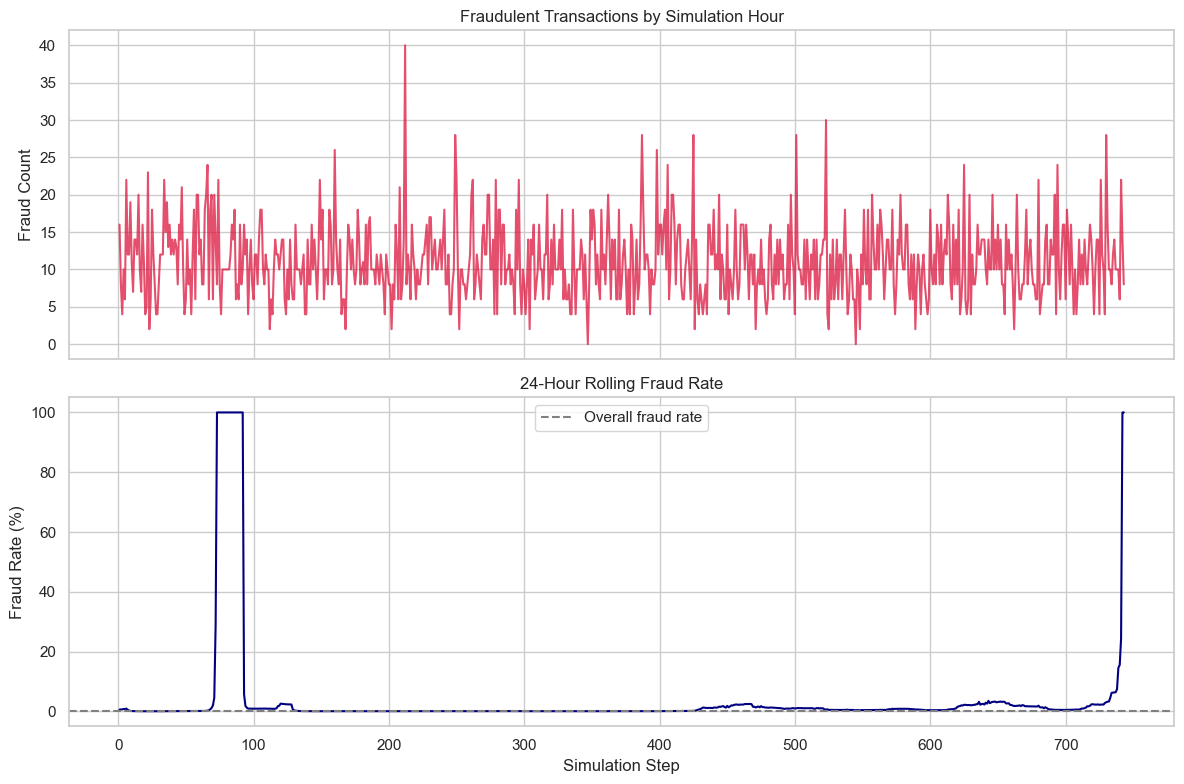

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    hourly_fraud.index,
    hourly_fraud["frauds"],
    color="crimson",
    alpha=0.75
)
axes[0].set_title("Fraudulent Transactions by Simulation Hour")
axes[0].set_ylabel("Fraud Count")

axes[1].plot(
    hourly_fraud.index,
    hourly_fraud["fraud_rate_24h"] * 100,
    color="navy"
)
axes[1].axhline(
    df_full["isFraud"].mean() * 100,
    color="gray",
    linestyle="--",
    label="Overall fraud rate"
)
axes[1].set_title("24-Hour Rolling Fraud Rate")
axes[1].set_xlabel("Simulation Step")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
fraud_df = df_full[df_full["isFraud"] == 1]

fraud_account_summary = pd.Series({
    "fraudulent_transactions": len(fraud_df),
    "unique_fraud_origins": fraud_df["nameOrig"].nunique(),
    "unique_fraud_destinations": fraud_df["nameDest"].nunique(),
    "repeated_fraud_origins": int(
        (fraud_df["nameOrig"].value_counts() > 1).sum()
    ),
    "repeated_fraud_destinations": int(
        (fraud_df["nameDest"].value_counts() > 1).sum()
    )
})

fraud_account_summary

fraudulent_transactions        8213
unique_fraud_origins           8213
unique_fraud_destinations      8169
repeated_fraud_origins            0
repeated_fraud_destinations      44
dtype: int64

In [25]:
relevant_types = df_full[
    df_full["type"].isin(["CASH_OUT", "TRANSFER"])
].copy()

relevant_types["sender_balance_error"] = (
    relevant_types["oldbalanceOrg"]
    - relevant_types["amount"]
    - relevant_types["newbalanceOrig"]
).abs()

relevant_types["receiver_balance_error"] = (
    relevant_types["oldbalanceDest"]
    + relevant_types["amount"]
    - relevant_types["newbalanceDest"]
).abs()

relevant_types["emptied_sender"] = (
    (relevant_types["oldbalanceOrg"] > 0)
    & (relevant_types["newbalanceOrig"] == 0)
).astype("int8")

controlled_balance_comparison = (
    relevant_types.groupby(["type", "isFraud"])
    .agg(
        transactions=("isFraud", "size"),
        median_amount=("amount", "median"),
        median_sender_error=("sender_balance_error", "median"),
        median_receiver_error=("receiver_balance_error", "median"),
        emptied_sender_rate=("emptied_sender", "mean")
    )
)

controlled_balance_comparison

transactions  median_amount  median_sender_error  \
type     isFraud                                                     
CASH_OUT 0             2233384     146946.560           119824.215   
         1                4116     435516.905                0.000   
TRANSFER 0              528812     486521.910           454033.080   
         1                4097     445705.760                0.000   

                  median_receiver_error  emptied_sender_rate  
type     isFraud                                              
CASH_OUT 0                         0.00             0.427752  
         1                         0.00             0.990768  
TRANSFER 0                         0.00             0.424968  
         1                    443893.69             0.960215

In [ ]:
modeling_df = df_full[df_full["amount"] > 0].copy()

print(f"Rows before cleaning: {len(df_full):,}")
print(f"Rows after cleaning:  {len(modeling_df):,}")
print(f"Removed:              {len(df_full) - len(modeling_df):,}")

# Sixteen zero-value records were labelled as fraudulent CASH_OUT transactions. Because 
# they represented no financial exposure and contained degenerate balance information, they were
#  documented as simulation anomalies and excluded from predictive modelling.

Rows before cleaning: 6,362,620
Rows after cleaning:  6,362,604
Removed:              16


In [27]:
# Every fraudulent transaction originated from a unique sender account, preventing meaningful sender-history or
# transaction-velocity modelling. Only 44 fraudulent destination accounts repeated, so account-history features
# were excluded from the initial model.

batch_size = 100_000

batch_df = df_full[["step", "amount", "isFraud"]].copy()

batch_df["transaction_batch"] = (
    np.arange(len(batch_df)) // batch_size
)

batch_summary = (
    batch_df.groupby("transaction_batch")
    .agg(
        transactions=("isFraud", "size"),
        frauds=("isFraud", "sum"),
        fraudulent_value=(
            "amount",
            lambda values: values[
                batch_df.loc[values.index, "isFraud"] == 1
            ].sum()
        ),
        first_step=("step", "min"),
        last_step=("step", "max")
    )
)

batch_summary["fraud_rate"] = (
    batch_summary["frauds"]
    / batch_summary["transactions"]
)

batch_summary.head()

,transactions,frauds,fraudulent_value,first_step,last_step,fraud_rate
transaction_batch,,,,,,
0,100000,116,62823097.20,1,10,0.00116
1,100000,31,30653202.79,10,13,0.00031
2,100000,34,40933726.10,13,15,0.00034
3,100000,25,18291480.82,15,18,0.00025
4,100000,27,41364311.05,18,20,0.00027


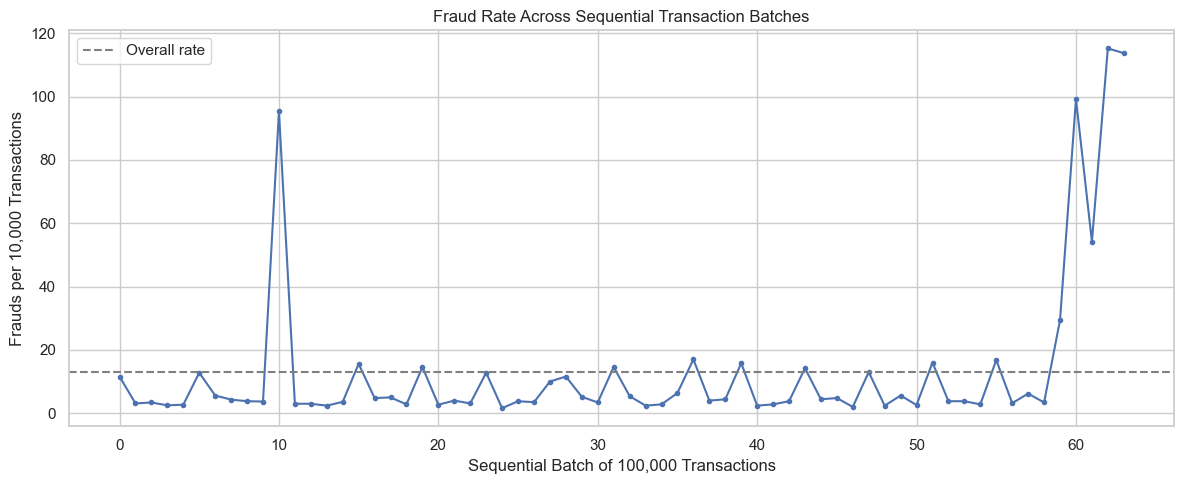

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    batch_summary.index,
    batch_summary["fraud_rate"] * 10_000,
    marker="o",
    markersize=3
)

plt.axhline(
    df_full["isFraud"].mean() * 10_000,
    color="gray",
    linestyle="--",
    label="Overall rate"
)

plt.title("Fraud Rate Across Sequential Transaction Batches")
plt.xlabel("Sequential Batch of 100,000 Transactions")
plt.ylabel("Frauds per 10,000 Transactions")
plt.legend()
plt.tight_layout()
plt.show()

## EDA Conclusions

1. Fraud is extremely rare by count but disproportionately large by
   transaction value, making class-sensitive and value-sensitive
   evaluation necessary.

2. Fraud occurs only in CASH_OUT and TRANSFER records in PaySim.
   This is a simulation characteristic and should not be generalized
   to real financial systems.

3. Transaction amount is associated with fraud overall, but its
   usefulness depends on transaction type. Fraudulent CASH_OUT
   transactions are substantially larger, while fraudulent and
   legitimate TRANSFER transactions have similar median values.

4. More than 96% of fraudulent transactions empty the sender's
   balance. However, this also occurs in approximately 42% of
   legitimate CASH_OUT and TRANSFER transactions, so it cannot be
   used as a standalone fraud rule.

5. Fraudulent records generally have zero sender-balance discrepancy.
   This strongly separates them from legitimate records in PaySim,
   but may reflect the dataset's simulation process.

6. Receiver-balance discrepancy is particularly informative for
   fraudulent TRANSFER transactions but not for CASH_OUT transactions,
   indicating an interaction between transaction type and balance
   behaviour.

7. Every fraudulent origin account appears only once. Consequently,
   sender-history and velocity features are not viable for this
   dataset.

8. Transaction volume varies drastically across simulation hours,
   making raw hourly fraud rates unstable. Time is retained for
   ordering and validation but excluded from the initial predictive
   feature set.

9. Sixteen zero-value fraudulent transactions were identified as
   simulation anomalies and excluded from predictive modelling because
   they represent no financial exposure.